# Part 1 - Vectorisation, Comparison, and Machine Learning

## 1. Aim

This notebook performs vectorisation, method comparison, clustering, and plotting for the cleaned datasets.

The goal is to compare different feature representations across text, image, and audio data, and evaluate how useful they are for:
- analysis
- clustering
- later parameter mapping into 3D generation

This notebook includes:
- vectorisation
- comparison between methods
- KMeans clustering
- PCA-based plotting

## 2. Methods Overview

### Text
- TF-IDF
- sentence embeddings

### Image
- handcrafted visual features

### Audio
- basic spectral features
- MFCC

### Machine Learning
- KMeans clustering

### Visualisation
- Matplotlib
- Seaborn
- PCA scatter plots

## 2.1 Machine Learning and Pretrained Models

This notebook uses machine learning in two ways:

1. **Pretrained representation models**  
   The sentence embedding model `all-MiniLM-L6-v2` is used as a pretrained language model to convert text fragments into semantic vectors. This avoids training a language model from scratch while still allowing the project to compare symbolic text features against semantic embeddings.

2. **Unsupervised clustering**  
   KMeans clustering is applied to text, image and audio features. The clusters are not treated as final categories, but as analytical groupings that help translate datasets into later design parameters for 3D generation.

This combination is appropriate for the project because the goal is not to build a predictive classifier, but to transform multimodal data into spatial and visual behaviours.


## 3. Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sentence_transformers import SentenceTransformer
import librosa

c:\Users\Greeny\anaconda3\envs\surface\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd().resolve().parent.parent

CLEANED_DIR = BASE_DIR / "data" / "cleaned"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

TEXT_CLEAN_DIR = CLEANED_DIR / "text"
IMAGE_CLEAN_DIR = CLEANED_DIR / "images"
AUDIO_CLEAN_DIR = CLEANED_DIR / "audio"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)

BASE_DIR: D:\Work\Workspace\Projects\Python\data-driven-surface


## 3.1 Figure output settings

The following folder is used to save key Matplotlib and Seaborn visualisations for the final report. Saving the figures here makes the analysis reusable in the PDF and keeps the notebook connected to the final submission material.


In [3]:
FIGURES_DIR = BASE_DIR / "outputs" / "figures" / "part1_vectorisation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Figure output folder:", FIGURES_DIR)


Figure output folder: D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\figures\part1_vectorisation


## 4. Load Cleaned Datasets

In [4]:
text_df = pd.read_csv(TEXT_CLEAN_DIR / "text_cleaned.csv")
image_df = pd.read_csv(IMAGE_CLEAN_DIR / "image_cleaned.csv")
audio_df = pd.read_csv(AUDIO_CLEAN_DIR / "audio_cleaned.csv")

print("Text rows:", len(text_df))
print("Image rows:", len(image_df))
print("Audio rows:", len(audio_df))

Text rows: 209
Image rows: 231
Audio rows: 350


## 5. Text Vectorisation

The text dataset is compared using two methods:
- TF-IDF
- sentence embeddings

TF-IDF provides interpretable word-based features.  
Embeddings provide a more semantic representation.

### 5.1 TF-IDF vectorisation

In [5]:
tfidf = TfidfVectorizer(max_features=1000, stop_words="english")
X_tfidf = tfidf.fit_transform(text_df["clean_text"])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (209, 1000)


### 5.2 Plot top TF-IDF terms

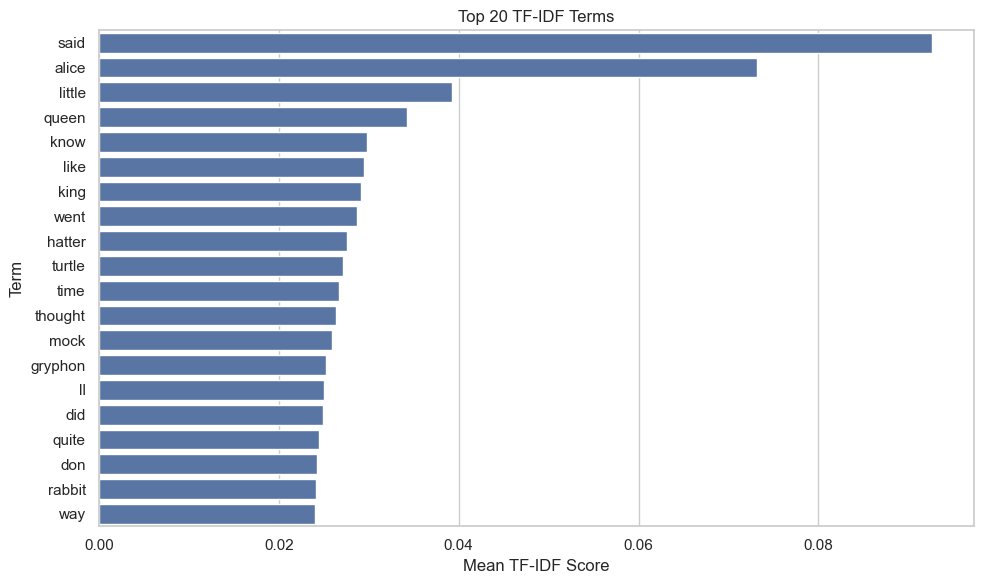

In [6]:
tfidf_means = np.asarray(X_tfidf.mean(axis=0)).ravel()
tfidf_terms = np.array(tfidf.get_feature_names_out())

top_n = 20
top_idx = np.argsort(tfidf_means)[-top_n:][::-1]

top_terms_df = pd.DataFrame({
    "term": tfidf_terms[top_idx],
    "score": tfidf_means[top_idx]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=top_terms_df, x="score", y="term")
plt.title("Top 20 TF-IDF Terms")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

### 5.3 Sentence embeddings

In [7]:
text_model = SentenceTransformer("all-MiniLM-L6-v2")
X_embed = text_model.encode(text_df["clean_text"].tolist(), show_progress_bar=True)

print("Embedding shape:", X_embed.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8013.01it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 7/7 [00:00<00:00, 18.22it/s]

Embedding shape: (209, 384)


### 5.4 KMeans clustering comparison

In [8]:
n_clusters = 5

text_kmeans_tfidf = KMeans(n_clusters=n_clusters, random_state=42)
text_df["tfidf_cluster"] = text_kmeans_tfidf.fit_predict(X_tfidf)

text_kmeans_embed = KMeans(n_clusters=n_clusters, random_state=42)
text_df["embed_cluster"] = text_kmeans_embed.fit_predict(X_embed)

text_df[["clean_text", "tfidf_cluster", "embed_cluster"]].head()

,clean_text,tfidf_cluster,embed_cluster
0,down the rabbit hole alice was beginning to ge...,2,2
1,i shall be late when she thought it over after...,2,2
2,the rabbit hole went straight on like a tunnel...,2,2
3,she took down a jar from one of the shelves as...,2,2
4,let me see that would be four thousand miles d...,0,2


### 5.5 PCA visualisation: TF-IDF

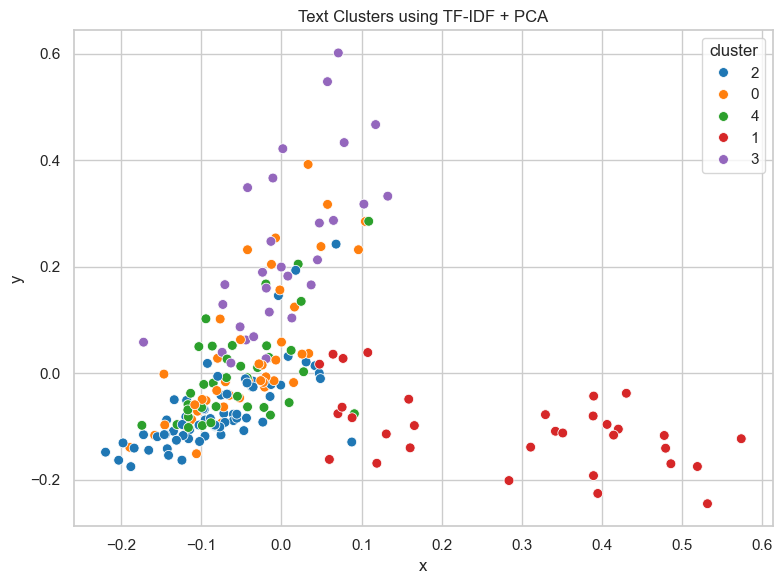

In [9]:
pca_tfidf = PCA(n_components=2)
X_tfidf_2d = pca_tfidf.fit_transform(X_tfidf.toarray())

tfidf_plot_df = pd.DataFrame({
    "x": X_tfidf_2d[:, 0],
    "y": X_tfidf_2d[:, 1],
    "cluster": text_df["tfidf_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tfidf_plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Text Clusters using TF-IDF + PCA")
plt.tight_layout()
plt.show()

### 5.6 PCA visualisation: embeddings

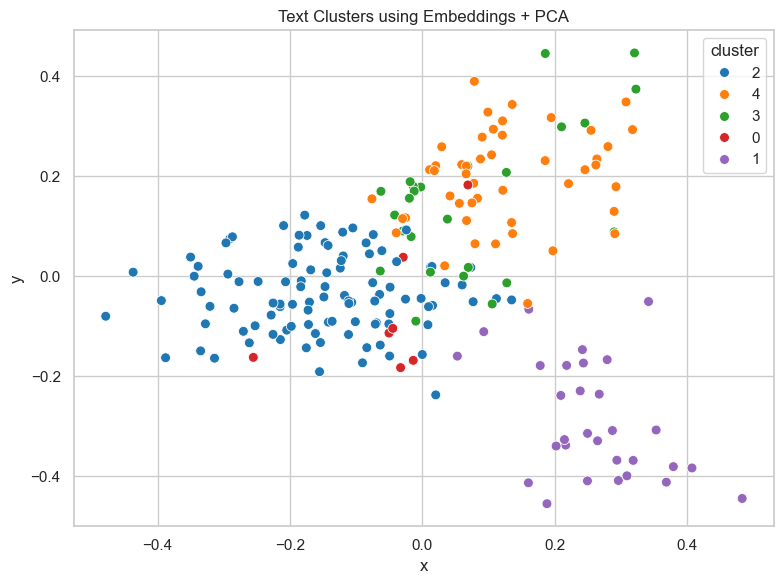

In [10]:
pca_embed = PCA(n_components=2)
X_embed_2d = pca_embed.fit_transform(X_embed)

embed_plot_df = pd.DataFrame({
    "x": X_embed_2d[:, 0],
    "y": X_embed_2d[:, 1],
    "cluster": text_df["embed_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=embed_plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Text Clusters using Embeddings + PCA")
plt.tight_layout()
plt.show()

### 5.7 Cluster size comparison

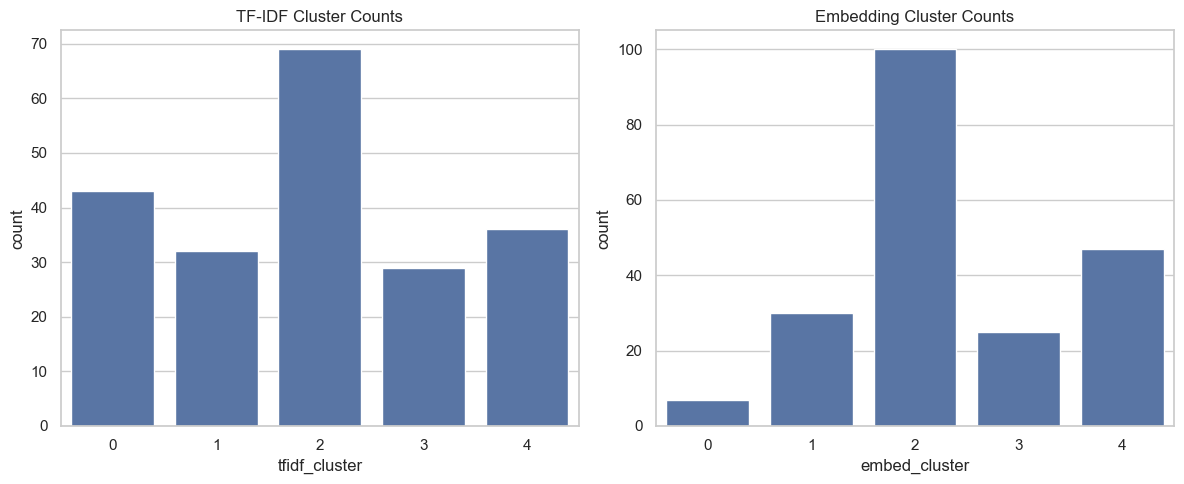

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=text_df, x="tfidf_cluster", ax=axes[0])
axes[0].set_title("TF-IDF Cluster Counts")

sns.countplot(data=text_df, x="embed_cluster", ax=axes[1])
axes[1].set_title("Embedding Cluster Counts")

plt.tight_layout()
plt.show()

### 5.8 Interim interpretation

TF-IDF is more interpretable because it reveals dominant keywords directly.  
Embeddings are expected to capture broader semantic similarity and may produce more coherent clusters.

The final judgement will be based on the visual cluster structure and later usefulness for design mapping.

## 6. Image Vectorisation

For the image dataset, the current comparison uses handcrafted visual features:
- brightness
- saturation
- edge density

These are especially useful because they can be directly mapped to geometric parameters later.

### 6.1 Inspect handcrafted image features

In [12]:
image_df[["brightness", "saturation", "edge_density"]].describe()

,brightness,saturation,edge_density
count,231.000000,231.000000,231.000000
mean,116.302603,101.514399,20.649082
std,43.045587,44.470964,14.925192
min,28.660992,0.000000,0.528202
25%,84.259619,71.074425,10.009575
50%,116.670284,93.870457,16.971531
75%,144.912216,132.719355,28.020487
max,246.073242,228.159084,83.827515


### 6.2 Plot brightness vs edge density

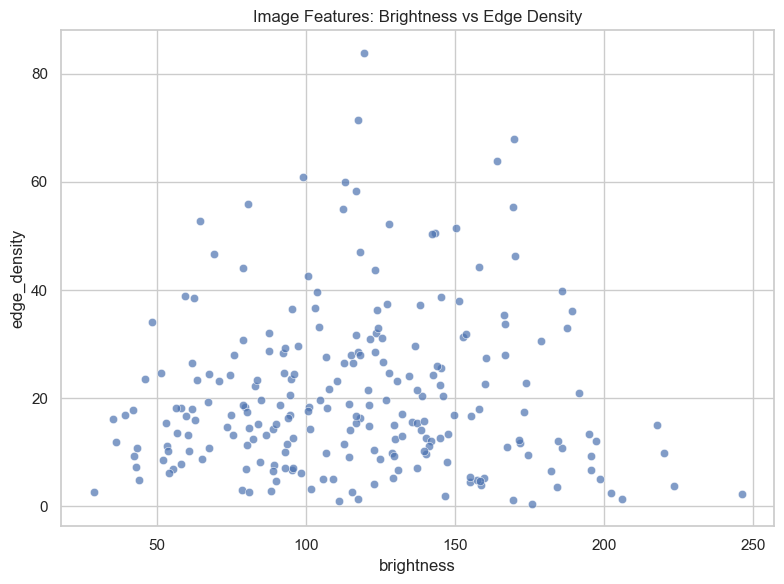

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=image_df, x="brightness", y="edge_density", alpha=0.7)
plt.title("Image Features: Brightness vs Edge Density")
plt.tight_layout()
plt.show()

### 6.3 Standardise image features

In [14]:
image_feature_cols = ["brightness", "saturation", "edge_density"]

image_scaler = StandardScaler()
X_image = image_scaler.fit_transform(image_df[image_feature_cols])

### 6.4 KMeans clustering on handcrafted image features

In [15]:
image_kmeans = KMeans(n_clusters=5, random_state=42)
image_df["image_cluster"] = image_kmeans.fit_predict(X_image)

image_df[["brightness", "saturation", "edge_density", "image_cluster"]].head()

,brightness,saturation,edge_density,image_cluster
0,152.730297,89.531120,31.253414,3
1,114.278633,105.534653,9.059200,0
2,149.746407,69.439190,16.839237,1
3,126.662529,79.775913,19.733162,0
4,80.581467,78.962467,55.836697,2


### 6.5 PCA visualisation for image clusters

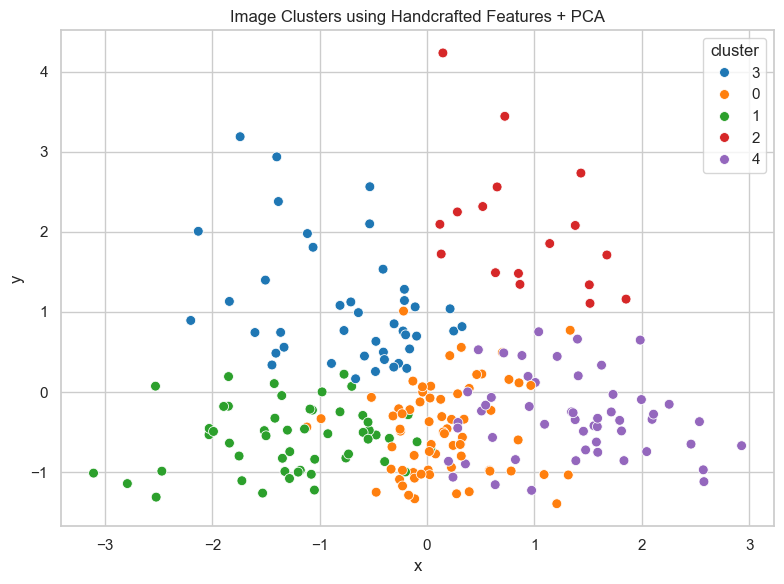

In [16]:
image_pca = PCA(n_components=2)
X_image_2d = image_pca.fit_transform(X_image)

image_plot_df = pd.DataFrame({
    "x": X_image_2d[:, 0],
    "y": X_image_2d[:, 1],
    "cluster": image_df["image_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=image_plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Image Clusters using Handcrafted Features + PCA")
plt.tight_layout()
plt.show()

### 6.6 Cluster count plot

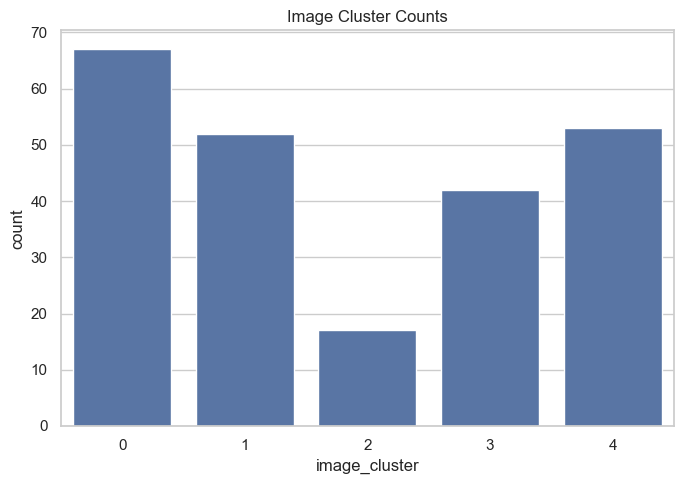

In [17]:
plt.figure(figsize=(7, 5))
sns.countplot(data=image_df, x="image_cluster")
plt.title("Image Cluster Counts")
plt.tight_layout()
plt.show()

### 6.7 Interim interpretation

Handcrafted image features are simple but effective for direct control tasks.
For example:
- brightness can later map to height or exposure-like spatial intensity
- saturation can later map to material intensity
- edge density can later map to complexity or fragmentation

## 7. Audio Vectorisation

The audio dataset is compared using:
- basic spectral features
- MFCC

Basic spectral features are more intuitive for direct animation and spatial control.  
MFCC provides a denser representation commonly used for machine listening and clustering.

### 7.1 Inspect existing audio features

In [18]:
audio_df[["duration_clean", "rms", "zcr", "spectral_centroid"]].describe()

,duration_clean,rms,zcr,spectral_centroid
count,350.000000,350.000000,350.000000,350.000000
mean,393.254838,0.037711,0.128326,2298.708129
std,816.071106,0.063235,0.116373,1275.280809
min,0.209206,0.000295,0.003258,173.895879
25%,30.372336,0.005098,0.051534,1435.565598
50%,76.559637,0.014851,0.088357,1974.981005
75%,254.230034,0.039157,0.164000,3003.746826
max,4812.443492,0.468115,0.606424,6597.733284


### 7.2 Plot basic audio features

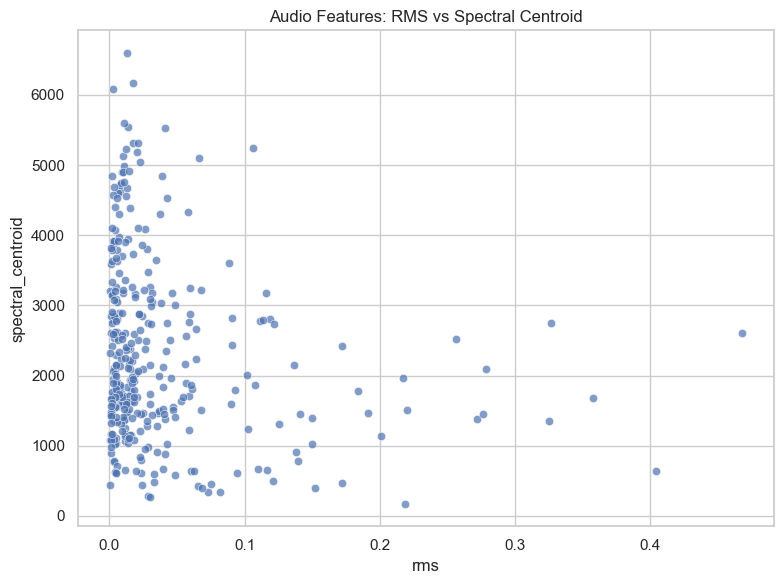

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=audio_df, x="rms", y="spectral_centroid", alpha=0.7)
plt.title("Audio Features: RMS vs Spectral Centroid")
plt.tight_layout()
plt.show()

### 7.3 KMeans clustering using basic spectral features

In [19]:
audio_feature_cols = ["duration_clean", "rms", "zcr", "spectral_centroid"]

audio_scaler = StandardScaler()
X_audio_basic = audio_scaler.fit_transform(audio_df[audio_feature_cols])

audio_kmeans_basic = KMeans(n_clusters=5, random_state=42)
audio_df["audio_basic_cluster"] = audio_kmeans_basic.fit_predict(X_audio_basic)

audio_df[audio_feature_cols + ["audio_basic_cluster"]].head()

,duration_clean,rms,zcr,spectral_centroid,audio_basic_cluster
0,9.771066,0.007996,0.212267,4631.344945,0
1,64.166168,0.075333,0.012516,457.364479,3
2,110.958549,0.065641,0.009511,430.598940,3
3,5.014059,0.056515,0.071999,1899.045851,3
4,3.959773,0.024671,0.060981,1473.670996,3


### 7.4 PCA visualisation for basic audio features

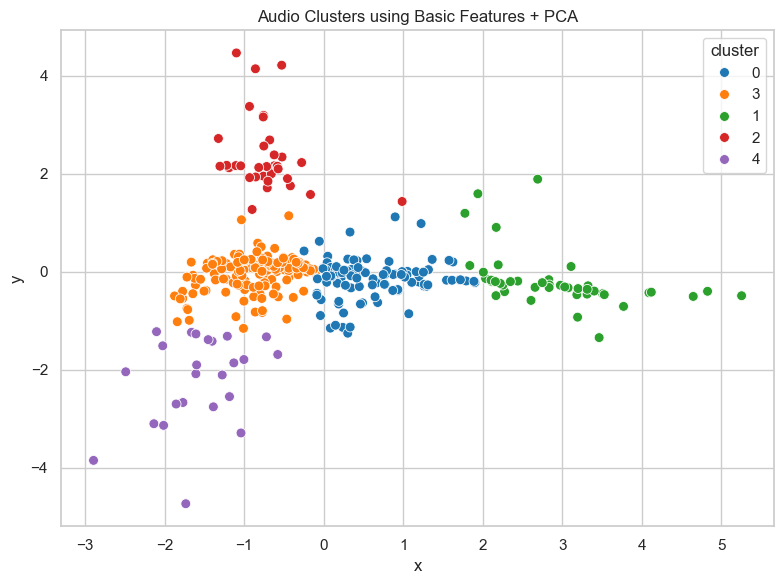

In [20]:
audio_pca_basic = PCA(n_components=2)
X_audio_basic_2d = audio_pca_basic.fit_transform(X_audio_basic)

audio_basic_plot_df = pd.DataFrame({
    "x": X_audio_basic_2d[:, 0],
    "y": X_audio_basic_2d[:, 1],
    "cluster": audio_df["audio_basic_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=audio_basic_plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Audio Clusters using Basic Features + PCA")
plt.tight_layout()
plt.show()

### 7.5 Extract MFCC features

In [21]:
def extract_mfcc_mean(path, n_mfcc=13):
    try:
        y, sr = librosa.load(path, sr=22050, mono=True)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return mfcc.mean(axis=1)
    except Exception:
        return np.array([np.nan] * n_mfcc)

In [23]:
mfcc_features = audio_df["local_path"].apply(extract_mfcc_mean)

mfcc_df = pd.DataFrame(mfcc_features.tolist(), columns=[f"mfcc_{i+1}" for i in range(13)])
audio_df = pd.concat([audio_df.reset_index(drop=True), mfcc_df.reset_index(drop=True)], axis=1)

audio_df.head()

,id,source,freesound_id,name,username,license,duration,tags,description,audio_url,...,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,audio_0000,freesound,383184,chattering teeth - winding up,ChrisReierson,https://creativecommons.org/licenses/by/4.0/,9.77104,"chattering, effect, funny, humor, mechanical, ...",Winding up a miniature chattering teeth toy. I...,https://cdn.freesound.org/previews/383/383184_...,...,33.929169,35.070141,3.665223,12.676740,24.985468,-0.580403,11.944828,11.509631,9.856079,-0.135622
1,audio_0001,freesound,383169,wind gap indoors 002 170305_1100.wav,klankbeeld,https://creativecommons.org/licenses/by/4.0/,64.16610,"air-flow, air-stream, ajar, ambience, ambient,...",The wind ajar trough a door-gap indoors (10cm ...,https://cdn.freesound.org/previews/383/383169_...,...,32.069248,14.342833,9.970692,19.562788,7.211043,-1.689108,5.835673,6.298986,0.652640,2.040185
2,audio_0002,freesound,383139,wind gap indoors 001 170305_1100.wav,klankbeeld,https://creativecommons.org/licenses/by/4.0/,110.95900,"air-flow, air-stream, ajar, ambience, ambient,...",The wind ajar trough a door-gap indoors (10cm ...,https://cdn.freesound.org/previews/383/383139_...,...,32.581482,18.085220,17.279411,18.613485,11.435266,5.035427,5.928708,7.180472,4.874164,3.737484
3,audio_0003,freesound,379470,Wind3.mp3,vandale,http://creativecommons.org/publicdomain/zero/1.0/,5.01406,"air, breeze, gust, swoosh, wind",wind breeze swoosh air gust,https://cdn.freesound.org/previews/379/379470_...,...,-22.549938,-14.503655,18.949230,13.211223,9.521394,8.244902,15.977033,0.953145,22.368374,0.740013
4,audio_0004,freesound,379467,Wind2.ogg,vandale,http://creativecommons.org/publicdomain/zero/1.0/,3.95977,"air, breeze, gust, swoosh, wind",wind breeze swoosh air gust,https://cdn.freesound.org/previews/379/379467_...,...,-22.601332,-19.684685,14.946421,-11.926103,14.356014,7.941669,13.710144,-5.580842,21.002539,1.594467


### 7.6 KMeans clustering using MFCC

In [24]:
mfcc_cols = [f"mfcc_{i+1}" for i in range(13)]

audio_mfcc_valid = audio_df.dropna(subset=mfcc_cols).copy()

audio_scaler_mfcc = StandardScaler()
X_audio_mfcc = audio_scaler_mfcc.fit_transform(audio_mfcc_valid[mfcc_cols])

audio_kmeans_mfcc = KMeans(n_clusters=5, random_state=42)
audio_mfcc_valid["audio_mfcc_cluster"] = audio_kmeans_mfcc.fit_predict(X_audio_mfcc)

audio_mfcc_valid[mfcc_cols + ["audio_mfcc_cluster"]].head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,audio_mfcc_cluster
0,-500.308411,2.047567,35.219711,33.929169,35.070141,3.665223,12.676740,24.985468,-0.580403,11.944828,11.509631,9.856079,-0.135622,1
1,-368.298798,164.781754,52.611958,32.069248,14.342833,9.970692,19.562788,7.211043,-1.689108,5.835673,6.298986,0.652640,2.040185,2
2,-394.160675,137.422470,68.251724,32.581482,18.085220,17.279411,18.613485,11.435266,5.035427,5.928708,7.180472,4.874164,3.737484,1
3,-333.248688,117.955711,32.067474,-22.549938,-14.503655,18.949230,13.211223,9.521394,8.244902,15.977033,0.953145,22.368374,0.740013,1
4,-359.624115,142.651596,25.984875,-22.601332,-19.684685,14.946421,-11.926103,14.356014,7.941669,13.710144,-5.580842,21.002539,1.594467,2


### 7.7 PCA visualisation for MFCC

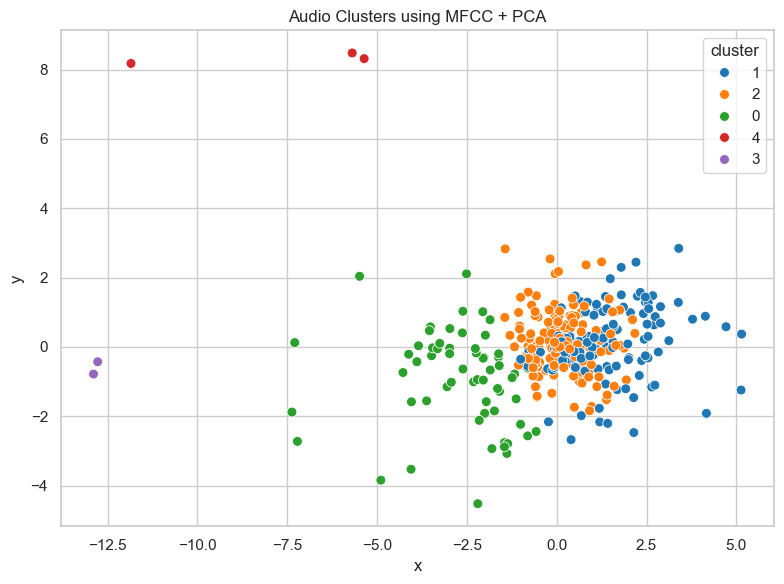

In [25]:
audio_pca_mfcc = PCA(n_components=2)
X_audio_mfcc_2d = audio_pca_mfcc.fit_transform(X_audio_mfcc)

audio_mfcc_plot_df = pd.DataFrame({
    "x": X_audio_mfcc_2d[:, 0],
    "y": X_audio_mfcc_2d[:, 1],
    "cluster": audio_mfcc_valid["audio_mfcc_cluster"].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=audio_mfcc_plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Audio Clusters using MFCC + PCA")
plt.tight_layout()
plt.show()

### 7.8 Compare cluster counts

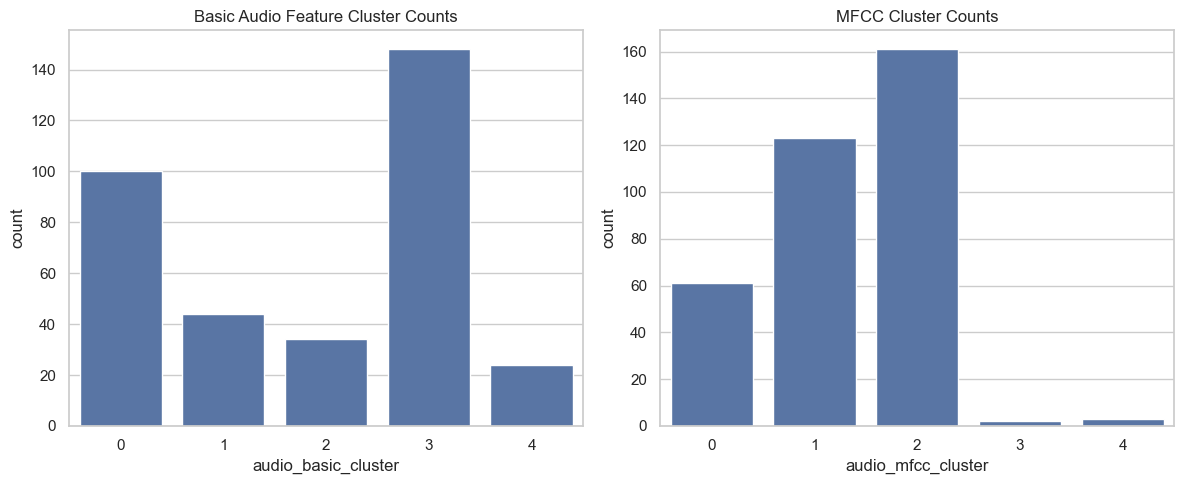

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=audio_df, x="audio_basic_cluster", ax=axes[0])
axes[0].set_title("Basic Audio Feature Cluster Counts")

sns.countplot(data=audio_mfcc_valid, x="audio_mfcc_cluster", ax=axes[1])
axes[1].set_title("MFCC Cluster Counts")

plt.tight_layout()
plt.show()

### 7.9 Interim interpretation

Basic spectral features are more intuitive and easier to map directly to animation parameters.  
MFCC provides a denser representation and may capture more nuanced sonic similarity.

The comparison is useful because one method may be better for direct control, while the other may be better for clustering quality.

## 8. Additional Visualisations for Report Export

The following cells generate and save additional analysis figures using Matplotlib and Seaborn. These plots do not change the processed datasets or the downstream parameter mapping. They are included to make the vectorisation and comparison stage more visible in the final PDF report.


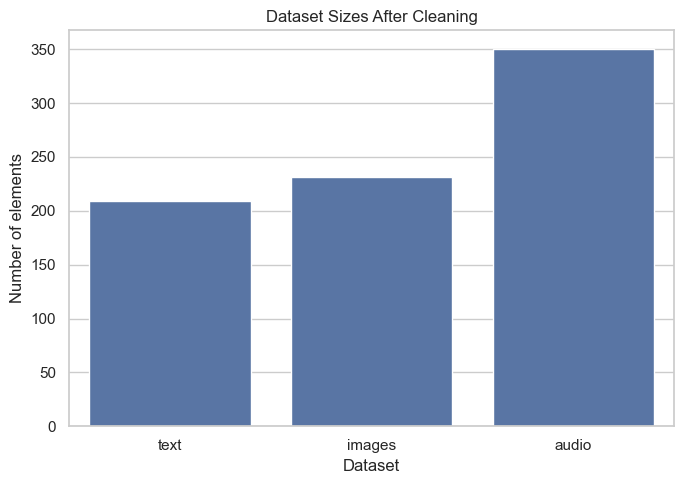

In [27]:
# Dataset size comparison
size_df = pd.DataFrame({
    "dataset": ["text", "images", "audio"],
    "count": [len(text_df), len(image_df), len(audio_df)]
})

plt.figure(figsize=(7, 5))
sns.barplot(data=size_df, x="dataset", y="count")
plt.title("Dataset Sizes After Cleaning")
plt.xlabel("Dataset")
plt.ylabel("Number of elements")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_dataset_sizes.png", dpi=300)
plt.show()


### 8.1 Text comparison figures

These figures compare the two text vectorisation approaches. The heatmap shows how TF-IDF clusters and embedding clusters relate to each other, while the PCA explained variance plots show how much of each representation can be summarised in two dimensions.


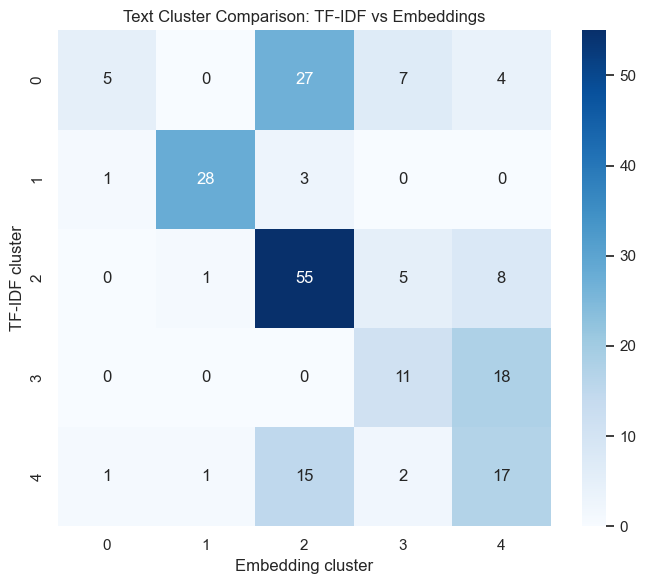

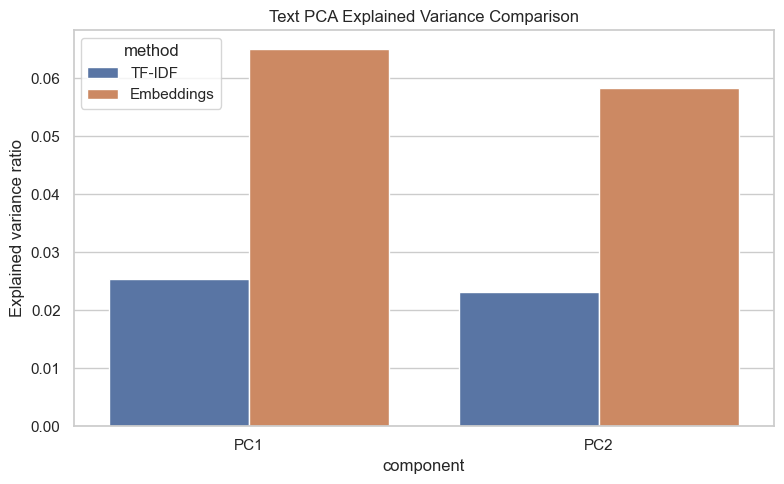

In [28]:
# Text cluster comparison heatmap
text_cluster_cross = pd.crosstab(text_df["tfidf_cluster"], text_df["embed_cluster"])

plt.figure(figsize=(7, 6))
sns.heatmap(text_cluster_cross, annot=True, fmt="d", cmap="Blues")
plt.title("Text Cluster Comparison: TF-IDF vs Embeddings")
plt.xlabel("Embedding cluster")
plt.ylabel("TF-IDF cluster")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_text_cluster_comparison_heatmap.png", dpi=300)
plt.show()

# PCA explained variance comparison
text_pca_variance_df = pd.DataFrame({
    "method": ["TF-IDF", "TF-IDF", "Embeddings", "Embeddings"],
    "component": ["PC1", "PC2", "PC1", "PC2"],
    "explained_variance": list(pca_tfidf.explained_variance_ratio_) + list(pca_embed.explained_variance_ratio_)
})

plt.figure(figsize=(8, 5))
sns.barplot(data=text_pca_variance_df, x="component", y="explained_variance", hue="method")
plt.title("Text PCA Explained Variance Comparison")
plt.ylabel("Explained variance ratio")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_text_pca_explained_variance.png", dpi=300)
plt.show()


### 8.2 Image feature figures

These plots show how the manually defined image features relate to each other. They are useful because these features later become direct controls for material, complexity and fragment behaviour.


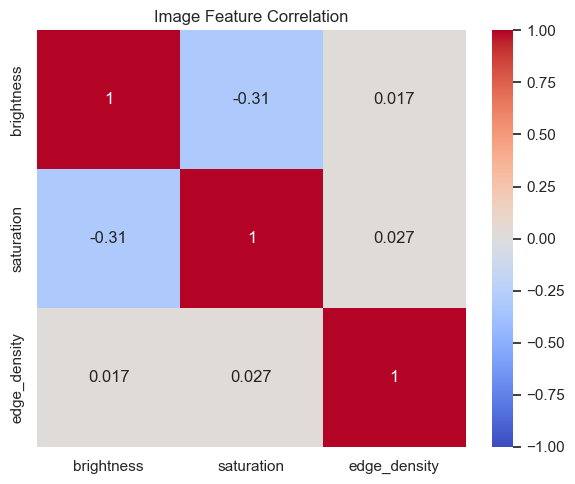

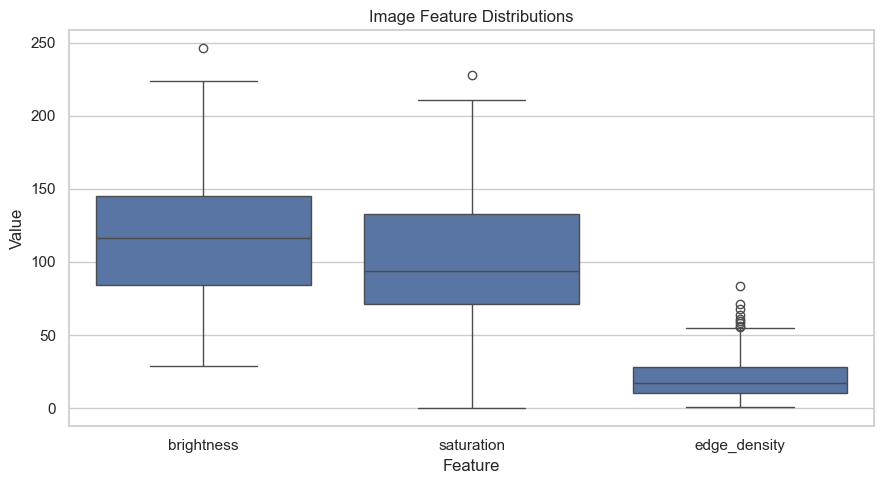

In [29]:
# Image feature correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(image_df[image_feature_cols].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Image Feature Correlation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_image_feature_correlation.png", dpi=300)
plt.show()

# Image feature distributions
image_long_df = image_df[image_feature_cols].melt(var_name="feature", value_name="value")

plt.figure(figsize=(9, 5))
sns.boxplot(data=image_long_df, x="feature", y="value")
plt.title("Image Feature Distributions")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_image_feature_distributions.png", dpi=300)
plt.show()


### 8.3 Audio comparison figures

The audio comparison is important because the project uses sound as a behavioural driver in TouchDesigner. Basic features are easier to interpret as animation controls, while MFCCs provide a richer machine-listening representation.


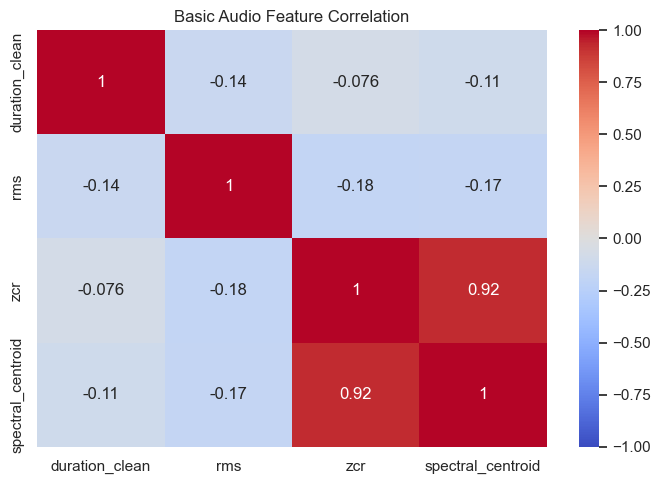

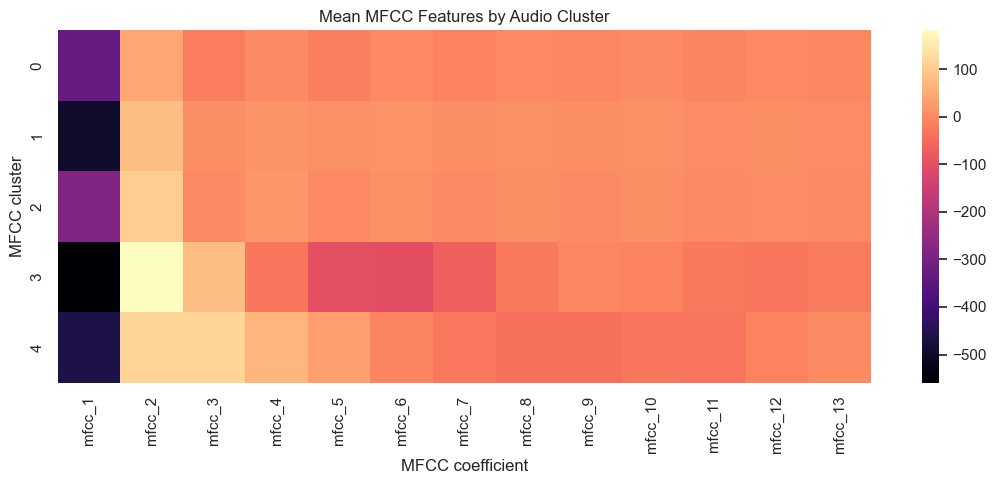

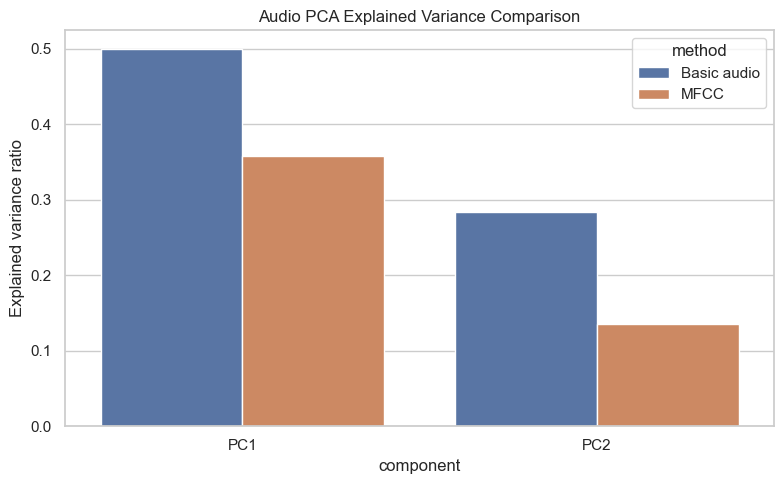

In [30]:
# Audio basic feature correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(audio_df[audio_feature_cols].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Basic Audio Feature Correlation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_audio_basic_feature_correlation.png", dpi=300)
plt.show()

# MFCC mean heatmap by cluster
mfcc_cluster_means = audio_mfcc_valid.groupby("audio_mfcc_cluster")[mfcc_cols].mean()

plt.figure(figsize=(11, 5))
sns.heatmap(mfcc_cluster_means, cmap="magma")
plt.title("Mean MFCC Features by Audio Cluster")
plt.xlabel("MFCC coefficient")
plt.ylabel("MFCC cluster")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_audio_mfcc_cluster_heatmap.png", dpi=300)
plt.show()

# Audio PCA explained variance comparison
audio_pca_variance_df = pd.DataFrame({
    "method": ["Basic audio", "Basic audio", "MFCC", "MFCC"],
    "component": ["PC1", "PC2", "PC1", "PC2"],
    "explained_variance": list(audio_pca_basic.explained_variance_ratio_) + list(audio_pca_mfcc.explained_variance_ratio_)
})

plt.figure(figsize=(8, 5))
sns.barplot(data=audio_pca_variance_df, x="component", y="explained_variance", hue="method")
plt.title("Audio PCA Explained Variance Comparison")
plt.ylabel("Explained variance ratio")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_audio_pca_explained_variance.png", dpi=300)
plt.show()


### 8.4 Saved figure list

This cell lists the figures exported from the notebook. These files can be used directly in the final PDF report.


In [31]:
saved_figures = sorted(FIGURES_DIR.glob("*.png"))

for fig_path in saved_figures:
    print(fig_path.name)

print(f"Saved {len(saved_figures)} figures to {FIGURES_DIR}")


01_dataset_sizes.png
02_text_cluster_comparison_heatmap.png
03_text_pca_explained_variance.png
04_image_feature_correlation.png
05_image_feature_distributions.png
06_audio_basic_feature_correlation.png
07_audio_mfcc_cluster_heatmap.png
08_audio_pca_explained_variance.png
Saved 8 figures to D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\figures\part1_vectorisation


## 9. Save Processed Outputs

The vectorisation outputs and cluster labels are saved for later use in parameter mapping and design integration.

In [32]:
text_df.to_csv(PROCESSED_DIR / "text_vectorised.csv", index=False, encoding="utf-8-sig")
image_df.to_csv(PROCESSED_DIR / "image_vectorised.csv", index=False, encoding="utf-8-sig")
audio_df.to_csv(PROCESSED_DIR / "audio_basic_vectorised.csv", index=False, encoding="utf-8-sig")
audio_mfcc_valid.to_csv(PROCESSED_DIR / "audio_mfcc_vectorised.csv", index=False, encoding="utf-8-sig")

print("Saved processed files to:", PROCESSED_DIR)

Saved processed files to: D:\Work\Workspace\Projects\Python\data-driven-surface\data\processed


## 10. Comparison Summary

This project uses different vectorisation methods because each dataset contains a different type of information.

### Text

TF-IDF is useful because it highlights words that are distinctive within the selected literary text. It is transparent and easy to interpret, which makes it suitable for linking textual themes to later design parameters. However, TF-IDF does not understand deeper semantic relationships between words, so it works better as an analytical baseline than as a full representation of meaning.

The sentence embedding model `all-MiniLM-L6-v2` provides a pretrained semantic representation. This is more suitable for grouping text fragments by meaning rather than by exact word frequency. The disadvantage is that embedding dimensions are less directly interpretable, so they require additional mapping before they can become design controls.

### Image

The image dataset uses handcrafted visual features such as brightness, saturation and edge density. These features are simple but highly useful for design mapping because they can be translated directly into spatial properties such as fragment density, material intensity and geometric complexity. The limitation is that they do not capture high-level visual meaning as strongly as pretrained visual models, but they are more controllable for this project.

### Audio

The audio dataset compares basic audio descriptors and MFCC features. Basic descriptors are useful for capturing direct properties such as loudness, duration and spectral centroid. These are easy to map to animation behaviours such as point vibration, switching intensity and rhythmic instability. MFCC features provide a richer description of timbre and spectral quality, making them more suitable for distinguishing between different sound textures. However, MFCCs are less intuitive to interpret directly and need further mapping before they can become design parameters.

Overall, the comparison shows that no single vectorisation method is best for all datasets. Basic features are more interpretable and easier to map to design controls, while pretrained or spectral features capture richer patterns that support more complex visual and spatial transformations. The outputs from this notebook therefore form both an analytical layer and a practical bridge toward the 3D generation workflows in Part 2.


## Next Step

The next notebook will focus on:
- structured parameter generation
- OpenAI API tagging for text
- mapping vectorised outputs to design variables
- preparing a parameter table for Blender / TouchDesigner / other 3D tools